In [9]:
from __future__ import annotations

import json
import re
import traceback
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

In [10]:
# ============================================================
# 1. CONFIG
# ============================================================
BIDS_ROOT = Path(r"D:\HUP dataset")
OUT_ROOT = Path(r"D:\HUP_processed_binary")

# Whole dataset
SUBJECTS = None
SESSIONS = None

# Accept ictal/interictal tasks
INCLUDE_TASK_KEYWORDS = ["ictal", "interictal"]
EDF_EXTENSIONS = [".edf"]

# Preprocessing for seizure detection
L_FREQ = 0.5
H_FREQ = 150.0
LINE_FREQ = 50.0
USE_CAR = True

# Windowing
WINDOW_LEN_SEC = 3.0
HOP_NONICTAL_SEC = 1.0
HOP_ICTAL_SEC = 0.25
MIN_ICTAL_OVERLAP_FRAC = 0.25

# Artifact rejection
ARTIFACT_RMS_ZTHRESH = 5.0
ARTIFACT_PEAK_ZTHRESH = 5.0
ABS_PEAK_UV_THRESHOLD = None

# Saving
SAVE_FLOAT32 = True
COMPRESS_NPZ = True
VERBOSE = True

# Example plotting
# Set one run you want to visualize before/after preprocessing
PLOT_EXAMPLE_RUN = Path(
    r"D:\HUP dataset\sub-HUP074\ses-presurgery\ieeg\sub-HUP074_ses-presurgery_task-ictal_acq-ecog_run-01_ieeg.edf"
)

# Plot settings
PLOT_CHANNELS = 8
PLOT_START_SEC = 115.0
PLOT_DURATION_SEC = 12.0

In [11]:
# ============================================================
# 2. DATA STRUCTURES
# ============================================================
@dataclass
class RunInfo:
    subject: str
    session: Optional[str]
    task: Optional[str]
    acquisition: Optional[str]
    run: Optional[str]
    edf_path: Path
    channels_tsv: Optional[Path]
    events_tsv: Optional[Path]


@dataclass
class QCStats:
    subject: str
    session: Optional[str]
    task: Optional[str]
    acquisition: Optional[str]
    run: Optional[str]
    edf_path: str
    sfreq: float
    n_channels_raw: int
    n_channels_kept: int
    n_bad_channels_from_tsv: int
    notch_freqs: str
    duration_sec: float
    n_windows_total: int
    n_windows_kept: int
    n_windows_dropped_artifact: int
    n_ictal_windows: int
    n_nonictal_windows: int
    notes: str

In [12]:
# ============================================================
# 3. HELPERS
# ============================================================
def vprint(*args, **kwargs):
    if VERBOSE:
        print(*args, **kwargs)


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def parse_bids_entities(path: Path) -> Dict[str, Optional[str]]:
    stem = path.stem

    entities = {
        "subject": None,
        "session": None,
        "task": None,
        "acquisition": None,
        "run": None,
    }

    m = re.search(r"(sub-[A-Za-z0-9]+)", str(path))
    if m:
        entities["subject"] = m.group(1)

    m = re.search(r"(ses-[A-Za-z0-9]+)", str(path))
    if m:
        entities["session"] = m.group(1)

    for key, patt in [
        ("task", r"_task-([^_]+)"),
        ("acquisition", r"_acq-([^_]+)"),
        ("run", r"_run-([^_]+)"),
    ]:
        m = re.search(patt, stem)
        if m:
            entities[key] = m.group(1)

    return entities


def find_sidecar_tsv(edf_path: Path, suffix: str) -> Optional[Path]:
    stem = edf_path.stem
    parent = edf_path.parent

    candidates = [
        parent / f"{stem.replace('_ieeg', '')}_{suffix}.tsv",
        parent / f"{stem}_{suffix}.tsv",
    ]

    for cand in candidates:
        if cand.exists():
            return cand

    shared_prefix = stem.replace("_ieeg", "")
    glob_candidates = sorted(parent.glob(f"{shared_prefix}*{suffix}.tsv"))
    if glob_candidates:
        return glob_candidates[0]

    return None


def discover_runs(
    bids_root: Path,
    subjects: Optional[List[str]] = None,
    sessions: Optional[List[str]] = None,
) -> List[RunInfo]:
    runs: List[RunInfo] = []
    all_edf = sorted([p for p in bids_root.rglob("*") if p.suffix.lower() in EDF_EXTENSIONS])

    for edf_path in all_edf:
        parts = parse_bids_entities(edf_path)
        subject = parts["subject"]
        session = parts["session"]
        task = parts["task"]
        acquisition = parts["acquisition"]
        run = parts["run"]

        if subject is None:
            continue

        if subjects is not None and subject not in subjects:
            continue

        if sessions is not None and session not in sessions:
            continue

        if INCLUDE_TASK_KEYWORDS:
            t = (task or "").lower()
            if not any(k in t for k in INCLUDE_TASK_KEYWORDS):
                continue

        channels_tsv = find_sidecar_tsv(edf_path, "channels")
        events_tsv = find_sidecar_tsv(edf_path, "events")

        runs.append(
            RunInfo(
                subject=subject,
                session=session,
                task=task,
                acquisition=acquisition,
                run=run,
                edf_path=edf_path,
                channels_tsv=channels_tsv,
                events_tsv=events_tsv,
            )
        )

    return runs


def read_channels_tsv(channels_tsv: Optional[Path]) -> pd.DataFrame:
    if channels_tsv is None or not channels_tsv.exists():
        return pd.DataFrame()
    df = pd.read_csv(channels_tsv, sep="\t")
    df.columns = [c.strip() for c in df.columns]
    return df


def extract_bad_channels(ch_df: pd.DataFrame) -> List[str]:
    if ch_df.empty:
        return []

    lower_cols = {c.lower(): c for c in ch_df.columns}
    name_col = lower_cols.get("name")
    status_col = lower_cols.get("status")

    if name_col is None or status_col is None:
        return []

    bad_mask = ch_df[status_col].astype(str).str.lower().isin(["bad", "excluded", "reject"])
    return ch_df.loc[bad_mask, name_col].astype(str).tolist()


def read_events_tsv(events_tsv: Optional[Path]) -> pd.DataFrame:
    if events_tsv is None or not events_tsv.exists():
        return pd.DataFrame()
    df = pd.read_csv(events_tsv, sep="\t")
    df.columns = [c.strip() for c in df.columns]
    return df


def normalize_event_text(x: str) -> str:
    return re.sub(r"\s+", " ", str(x).strip().lower())


def merge_intervals(intervals: List[Tuple[float, float]]) -> List[Tuple[float, float]]:
    if not intervals:
        return []

    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]

    for st, ed in intervals[1:]:
        last_st, last_ed = merged[-1]
        if st <= last_ed:
            merged[-1] = (last_st, max(last_ed, ed))
        else:
            merged.append((st, ed))

    return merged


def infer_ictal_intervals(events_df: pd.DataFrame, file_duration: float) -> List[Tuple[float, float]]:
    """
    Parse seizure intervals from events.tsv.
    Supported patterns:
      1) rows with onset + duration and text mentioning seizure/ictal/sz
      2) separate onset/offset rows such as 'sz onset' and 'sz offset'
    """
    if events_df.empty:
        return []

    cols = {c.lower(): c for c in events_df.columns}
    onset_col = cols.get("onset")
    duration_col = cols.get("duration")

    desc_candidates = [cols.get(k) for k in ["trial_type", "event_type", "label", "description", "value"]]
    desc_candidates = [c for c in desc_candidates if c is not None]

    intervals: List[Tuple[float, float]] = []

    # Case 1: rows with onset + duration
    if onset_col is not None and duration_col is not None and desc_candidates:
        desc_text = pd.Series([""] * len(events_df), index=events_df.index)
        for c in desc_candidates:
            desc_text = desc_text + " " + events_df[c].astype(str)

        desc_norm = desc_text.map(normalize_event_text)
        mask = desc_norm.str.contains(r"seiz|ictal|sz", regex=True)

        subset = events_df.loc[mask].copy()
        for _, row in subset.iterrows():
            try:
                start = float(row[onset_col])
                dur = float(row[duration_col]) if pd.notna(row[duration_col]) else 0.0
                end = start + max(dur, 0.0)
                if end > start:
                    intervals.append((max(0.0, start), min(file_duration, end)))
            except Exception:
                pass

        if intervals:
            return merge_intervals(intervals)

    # Case 2: onset/offset rows
    if onset_col is not None and desc_candidates:
        tmp = events_df.copy()
        desc_text = pd.Series([""] * len(tmp), index=tmp.index)
        for c in desc_candidates:
            desc_text = desc_text + " " + tmp[c].astype(str)
        tmp["_desc_norm"] = desc_text.map(normalize_event_text)

        onset_mask = tmp["_desc_norm"].str.contains(
            r"(seizure|ictal|sz).*(onset|start)|onset.*(seizure|ictal|sz)",
            regex=True
        )
        offset_mask = tmp["_desc_norm"].str.contains(
            r"(seizure|ictal|sz).*(offset|end|stop)|offset.*(seizure|ictal|sz)|end.*(seizure|ictal|sz)",
            regex=True
        )

        onset_times = [float(x) for x in tmp.loc[onset_mask, onset_col].tolist() if pd.notna(x)]
        offset_times = [float(x) for x in tmp.loc[offset_mask, onset_col].tolist() if pd.notna(x)]

        onset_times = sorted(onset_times)
        offset_times = sorted(offset_times)

        if onset_times and offset_times:
            used_offsets = set()
            for st in onset_times:
                ed = None
                for j, off in enumerate(offset_times):
                    if j in used_offsets:
                        continue
                    if off > st:
                        ed = off
                        used_offsets.add(j)
                        break
                if ed is not None:
                    intervals.append((max(0.0, st), min(file_duration, ed)))

        if intervals:
            return merge_intervals(intervals)

    return []


def compute_notch_freqs(line_freq: float, sfreq: float, high_freq: float) -> List[float]:
    max_f = min(high_freq, sfreq / 2.0 - 1.0)
    freqs = []
    k = 1
    while k * line_freq < max_f:
        freqs.append(k * line_freq)
        k += 1
    return freqs


def robust_zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad < 1e-12:
        return np.zeros_like(x)
    return 0.6745 * (x - med) / mad


def overlap_fraction(a0: float, a1: float, b0: float, b1: float) -> float:
    inter = max(0.0, min(a1, b1) - max(a0, b0))
    denom = max(a1 - a0, 1e-12)
    return inter / denom


def label_window_binary(win_start: float, win_end: float, ictal_intervals: List[Tuple[float, float]]) -> int:
    for st, ed in ictal_intervals:
        if overlap_fraction(win_start, win_end, st, ed) >= MIN_ICTAL_OVERLAP_FRAC:
            return 1
    return 0


def build_variable_hop_windows(
    duration_sec: float,
    window_len_sec: float,
    ictal_intervals: List[Tuple[float, float]],
    hop_nonictal_sec: float,
    hop_ictal_sec: float,
) -> List[Tuple[float, float, int]]:
    windows: List[Tuple[float, float, int]] = []
    t = 0.0
    while t + window_len_sec <= duration_sec + 1e-9:
        start = t
        end = t + window_len_sec
        label = label_window_binary(start, end, ictal_intervals)
        windows.append((start, end, label))
        t += hop_ictal_sec if label == 1 else hop_nonictal_sec
    return windows


def compute_window_artifact_features(
    data_uv: np.ndarray,
    starts_samp: np.ndarray,
    win_len_samp: int,
) -> Tuple[np.ndarray, np.ndarray]:
    n_windows = len(starts_samp)
    rms_vals = np.zeros(n_windows, dtype=np.float64)
    peak_vals = np.zeros(n_windows, dtype=np.float64)

    for i, s0 in enumerate(starts_samp):
        seg = data_uv[:, s0:s0 + win_len_samp]
        rms_vals[i] = np.sqrt(np.mean(seg ** 2))
        peak_vals[i] = np.max(np.abs(seg))

    return rms_vals, peak_vals

In [13]:
# ============================================================
# 4. PLOTTING UTILITIES
# ============================================================
def load_raw_and_drop_bad_channels(edf_path: Path, channels_tsv: Optional[Path]) -> mne.io.BaseRaw:
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")

    # Modern replacement for legacy pick_types()
    keep_names = []
    for ch_name, ch_type in zip(raw.ch_names, raw.get_channel_types()):
        if ch_type in ["eeg", "ecog", "seeg"]:
            keep_names.append(ch_name)

    if keep_names:
        raw.pick(keep_names)

    ch_df = read_channels_tsv(channels_tsv)
    if not ch_df.empty:
        bads_from_tsv = extract_bad_channels(ch_df)
        present_bads = [ch for ch in bads_from_tsv if ch in raw.ch_names]
        if present_bads:
            raw.drop_channels(present_bads)

    return raw


def preprocess_raw_only(raw: mne.io.BaseRaw, sfreq: float) -> mne.io.BaseRaw:
    raw_pp = raw.copy()

    notch_freqs = compute_notch_freqs(LINE_FREQ, sfreq, H_FREQ)
    if notch_freqs:
        raw_pp.notch_filter(freqs=notch_freqs, verbose="ERROR")

    raw_pp.filter(
        l_freq=L_FREQ,
        h_freq=H_FREQ,
        method="fir",
        phase="zero-double",
        verbose="ERROR"
    )

    if USE_CAR:
        raw_pp.set_eeg_reference(ref_channels="average", verbose="ERROR")

    return raw_pp


def plot_before_after_preprocessing(
    edf_path: Path,
    channels_tsv: Optional[Path],
    start_sec: float = 0.0,
    duration_sec: float = 10.0,
    n_channels: int = 8,
):
    if not edf_path.exists():
        print(f"Plot example run not found: {edf_path}")
        return

    raw_before = load_raw_and_drop_bad_channels(edf_path, channels_tsv)
    sfreq = float(raw_before.info["sfreq"])
    raw_after = preprocess_raw_only(raw_before.copy(), sfreq)

    start_samp = int(start_sec * sfreq)
    stop_samp = int((start_sec + duration_sec) * sfreq)

    ch_names = raw_before.ch_names[:min(n_channels, len(raw_before.ch_names))]
    raw_before_pick = raw_before.copy().pick(ch_names)
    raw_after_pick = raw_after.copy().pick(ch_names)

    data_before, times = raw_before_pick[:, start_samp:stop_samp]
    data_after, _ = raw_after_pick[:, start_samp:stop_samp]

    data_before_uv = data_before * 1e6
    data_after_uv = data_after * 1e6

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # stacked traces before
    spacing_before = np.nanpercentile(np.abs(data_before_uv), 95)
    spacing_before = max(spacing_before * 2.5, 50.0)

    for i in range(data_before_uv.shape[0]):
        axes[0].plot(times, data_before_uv[i] + i * spacing_before, linewidth=0.8)
    axes[0].set_title(f"Before preprocessing: {edf_path.name}")
    axes[0].set_ylabel("Amplitude + offset (uV)")
    axes[0].set_yticks([i * spacing_before for i in range(len(ch_names))])
    axes[0].set_yticklabels(ch_names)

    # stacked traces after
    spacing_after = np.nanpercentile(np.abs(data_after_uv), 95)
    spacing_after = max(spacing_after * 2.5, 50.0)

    for i in range(data_after_uv.shape[0]):
        axes[1].plot(times, data_after_uv[i] + i * spacing_after, linewidth=0.8)
    axes[1].set_title("After preprocessing")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Amplitude + offset (uV)")
    axes[1].set_yticks([i * spacing_after for i in range(len(ch_names))])
    axes[1].set_yticklabels(ch_names)

    plt.tight_layout()
    plt.show()

    # Optional single-channel zoom comparison
    if len(ch_names) > 0:
        fig, ax = plt.subplots(figsize=(16, 4))
        ax.plot(times, data_before_uv[0], label=f"Before: {ch_names[0]}", linewidth=0.9)
        ax.plot(times, data_after_uv[0], label=f"After: {ch_names[0]}", linewidth=0.9)
        ax.set_title(f"Single-channel comparison: {ch_names[0]}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude (uV)")
        ax.legend()
        plt.tight_layout()
        plt.show()

In [14]:
# ============================================================
# 5. CORE PREPROCESSING FOR ONE RUN
# ============================================================
def preprocess_one_run(run: RunInfo, out_root: Path) -> QCStats:
    notes = []
    vprint(f"\n[RUN] {run.edf_path}")

    # ----------------------------
    # Load EDF
    # ----------------------------
    raw = mne.io.read_raw_edf(run.edf_path, preload=True, verbose="ERROR")

    # Modern replacement for pick_types()
    keep_names = []
    for ch_name, ch_type in zip(raw.ch_names, raw.get_channel_types()):
        if ch_type in ["eeg", "ecog", "seeg"]:
            keep_names.append(ch_name)

    if keep_names:
        raw.pick(keep_names)

    sfreq = float(raw.info["sfreq"])
    duration_sec = raw.n_times / sfreq
    n_channels_raw = len(raw.ch_names)

    # ----------------------------
    # Drop bad channels from channels.tsv
    # ----------------------------
    bads_from_tsv = []
    ch_df = read_channels_tsv(run.channels_tsv)
    if not ch_df.empty:
        bads_from_tsv = extract_bad_channels(ch_df)
        present_bads = [ch for ch in bads_from_tsv if ch in raw.ch_names]
        if present_bads:
            raw.drop_channels(present_bads)
            notes.append(f"dropped {len(present_bads)} bad channels from channels.tsv")

    n_channels_kept = len(raw.ch_names)

    # ----------------------------
    # Notch with harmonics
    # ----------------------------
    notch_freqs = compute_notch_freqs(LINE_FREQ, sfreq, H_FREQ)
    if notch_freqs:
        raw.notch_filter(freqs=notch_freqs, verbose="ERROR")
        notes.append(f"notch {notch_freqs}")

    # ----------------------------
    # Bandpass
    # ----------------------------
    raw.filter(
        l_freq=L_FREQ,
        h_freq=H_FREQ,
        method="fir",
        phase="zero-double",
        verbose="ERROR"
    )
    notes.append(f"bandpass {L_FREQ}-{H_FREQ} Hz")

    # ----------------------------
    # CAR
    # ----------------------------
    if USE_CAR:
        raw.set_eeg_reference(ref_channels="average", verbose="ERROR")
        notes.append("common average reference")

    data = raw.get_data() * 1e6  # microvolts

    # ----------------------------
    # Events / seizure intervals
    # ----------------------------
    events_df = read_events_tsv(run.events_tsv)
    ictal_intervals = infer_ictal_intervals(events_df, duration_sec)

    # Fallback only for ictal task
    if not ictal_intervals and (run.task or "").lower() == "ictal":
        ictal_intervals = [(0.0, duration_sec)]
        notes.append("events.tsv missing/ambiguous; fallback=whole ictal file labeled ictal")

    # ----------------------------
    # Windowing
    # ----------------------------
    windows = build_variable_hop_windows(
        duration_sec=duration_sec,
        window_len_sec=WINDOW_LEN_SEC,
        ictal_intervals=ictal_intervals,
        hop_nonictal_sec=HOP_NONICTAL_SEC,
        hop_ictal_sec=HOP_ICTAL_SEC,
    )

    if not windows:
        raise RuntimeError("No windows were generated for this run.")

    win_len_samp = int(round(WINDOW_LEN_SEC * sfreq))
    starts_samp = np.array([int(round(w[0] * sfreq)) for w in windows], dtype=np.int64)
    labels = np.array([w[2] for w in windows], dtype=np.int64)
    time_bounds = np.array([[w[0], w[1]] for w in windows], dtype=np.float64)

    # ----------------------------
    # Artifact rejection
    # ----------------------------
    rms_vals, peak_vals = compute_window_artifact_features(data, starts_samp, win_len_samp)
    rms_z = np.abs(robust_zscore(rms_vals))
    peak_z = np.abs(robust_zscore(peak_vals))

    keep_mask = (rms_z <= ARTIFACT_RMS_ZTHRESH) & (peak_z <= ARTIFACT_PEAK_ZTHRESH)
    if ABS_PEAK_UV_THRESHOLD is not None:
        keep_mask &= (peak_vals <= ABS_PEAK_UV_THRESHOLD)

    kept_idx = np.where(keep_mask)[0]
    dropped_idx = np.where(~keep_mask)[0]

    x_list = []
    y_list = []
    t_list = []
    rms_list = []
    peak_list = []

    for i in kept_idx:
        s0 = starts_samp[i]
        seg = data[:, s0:s0 + win_len_samp]
        if seg.shape[1] != win_len_samp:
            continue
        x_list.append(seg.astype(np.float32 if SAVE_FLOAT32 else np.float64, copy=False))
        y_list.append(labels[i])
        t_list.append(time_bounds[i])
        rms_list.append(rms_vals[i])
        peak_list.append(peak_vals[i])

    if not x_list:
        raise RuntimeError("All windows were rejected. Check thresholds or data quality.")

    X = np.stack(x_list, axis=0)
    y = np.asarray(y_list, dtype=np.int64)
    t_bounds = np.asarray(t_list, dtype=np.float64)
    rms_kept = np.asarray(rms_list, dtype=np.float32)
    peak_kept = np.asarray(peak_list, dtype=np.float32)

    # ----------------------------
    # Save outputs
    # ----------------------------
    subj_out = out_root / run.subject
    ensure_dir(subj_out)

    tag_parts = [run.subject]
    if run.session:
        tag_parts.append(run.session)
    if run.task:
        tag_parts.append(f"task-{run.task}")
    if run.acquisition:
        tag_parts.append(f"acq-{run.acquisition}")
    if run.run:
        tag_parts.append(f"run-{run.run}")

    out_stem = "_".join(tag_parts)
    out_npz = subj_out / f"{out_stem}_windows.npz"
    out_json = subj_out / f"{out_stem}_meta.json"

    save_fn = np.savez_compressed if COMPRESS_NPZ else np.savez
    save_fn(
        out_npz,
        X=X,
        y=y,
        t_bounds=t_bounds,
        channel_names=np.array(raw.ch_names, dtype=object),
        sfreq=np.array([sfreq], dtype=np.float64),
        ictal_intervals=np.array(ictal_intervals, dtype=np.float64) if ictal_intervals else np.empty((0, 2), dtype=np.float64),
        rms_uV=rms_kept,
        peak_uV=peak_kept,
    )

    meta = {
        "run_info": {
            "subject": run.subject,
            "session": run.session,
            "task": run.task,
            "acquisition": run.acquisition,
            "run": run.run,
            "edf_path": str(run.edf_path),
            "channels_tsv": str(run.channels_tsv) if run.channels_tsv else None,
            "events_tsv": str(run.events_tsv) if run.events_tsv else None,
        },
        "sfreq": sfreq,
        "window_len_sec": WINDOW_LEN_SEC,
        "hop_nonictal_sec": HOP_NONICTAL_SEC,
        "hop_ictal_sec": HOP_ICTAL_SEC,
        "label_definition": {
            "0": "nonictal",
            "1": "ictal",
            "min_ictal_overlap_frac": MIN_ICTAL_OVERLAP_FRAC,
        },
        "artifact_rule": {
            "rms_z_thresh": ARTIFACT_RMS_ZTHRESH,
            "peak_z_thresh": ARTIFACT_PEAK_ZTHRESH,
            "abs_peak_uV_threshold": ABS_PEAK_UV_THRESHOLD,
        },
        "filters": {
            "line_freq": LINE_FREQ,
            "notch_freqs": notch_freqs,
            "bandpass": [L_FREQ, H_FREQ],
            "use_car": USE_CAR,
        },
        "channel_names": raw.ch_names,
        "ictal_intervals_sec": ictal_intervals,
        "notes": notes,
    }

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    qc = QCStats(
        subject=run.subject,
        session=run.session,
        task=run.task,
        acquisition=run.acquisition,
        run=run.run,
        edf_path=str(run.edf_path),
        sfreq=sfreq,
        n_channels_raw=n_channels_raw,
        n_channels_kept=n_channels_kept,
        n_bad_channels_from_tsv=len(bads_from_tsv),
        notch_freqs=",".join(f"{z:g}" for z in notch_freqs),
        duration_sec=duration_sec,
        n_windows_total=len(windows),
        n_windows_kept=int(len(y)),
        n_windows_dropped_artifact=int(len(dropped_idx)),
        n_ictal_windows=int(np.sum(y == 1)),
        n_nonictal_windows=int(np.sum(y == 0)),
        notes=" | ".join(notes),
    )

    vprint(
        f"  sfreq={sfreq:.3f} Hz | channels kept={n_channels_kept}/{n_channels_raw} | "
        f"windows kept={len(y)}/{len(windows)} | ictal={np.sum(y==1)} | nonictal={np.sum(y==0)}"
    )

    return qc

In [15]:
# ============================================================
# 6. DISCOVER RUNS
# ============================================================
ensure_dir(OUT_ROOT)

runs = discover_runs(
    bids_root=BIDS_ROOT,
    subjects=SUBJECTS,
    sessions=SESSIONS,
)

print(f"Found {len(runs)} run(s).")
if len(runs) == 0:
    print("Check BIDS_ROOT and naming structure.")

Found 319 run(s).



Plotting example run:
D:\HUP dataset\sub-HUP074\ses-presurgery\ieeg\sub-HUP074_ses-presurgery_task-ictal_acq-ecog_run-01_ieeg.edf


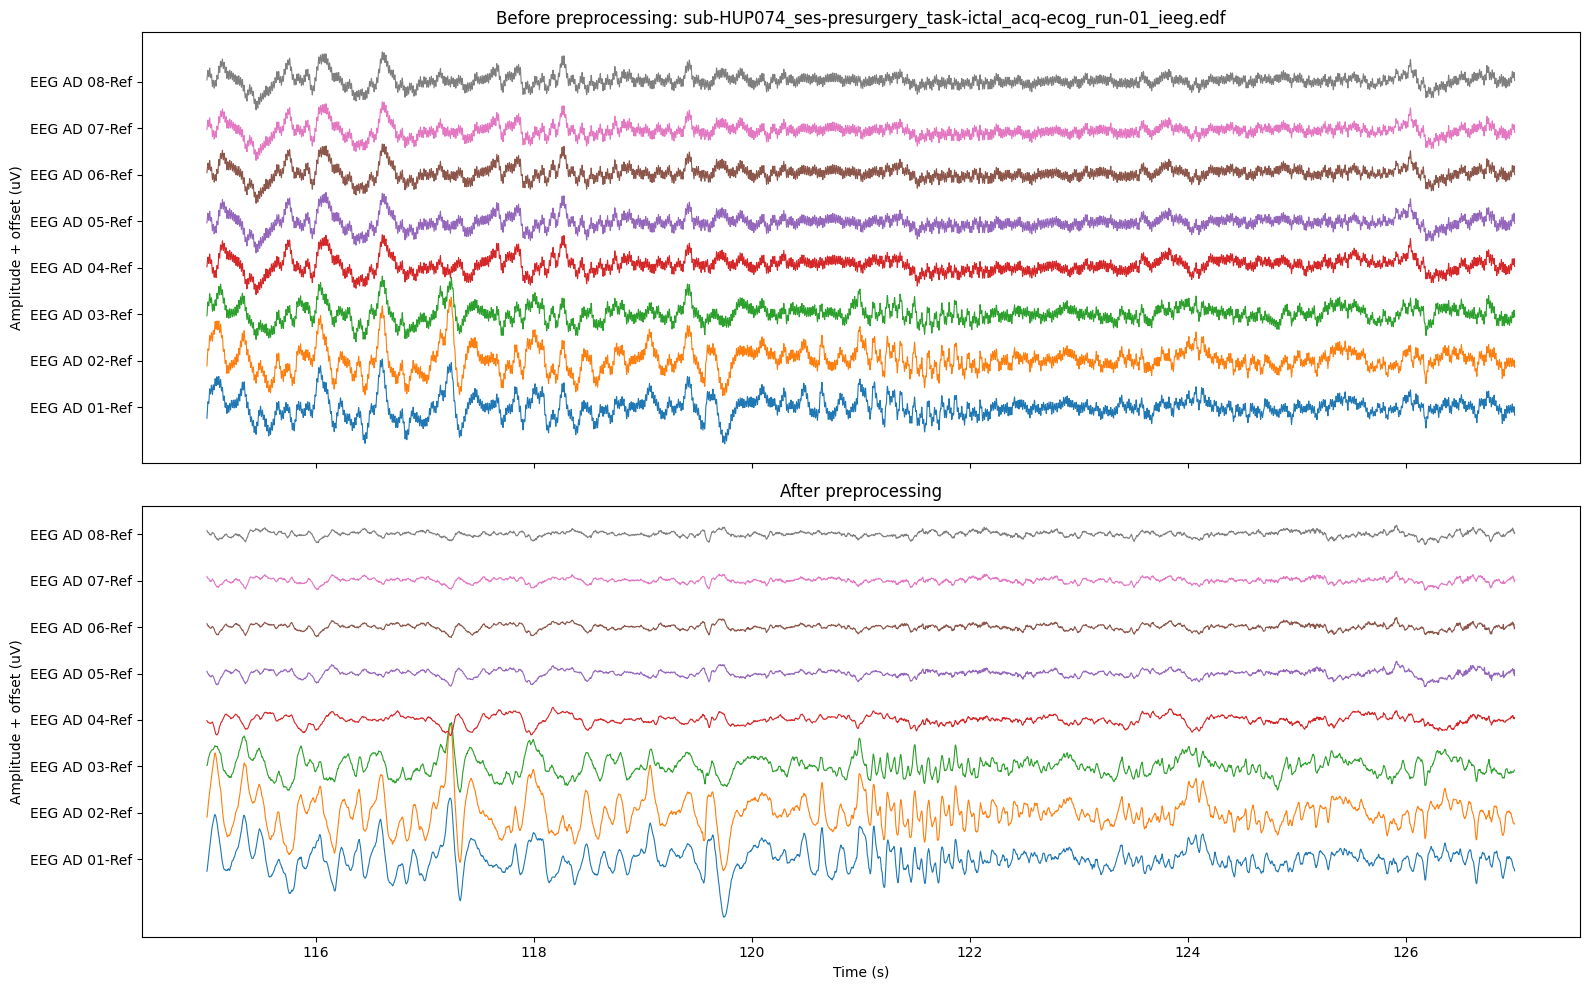

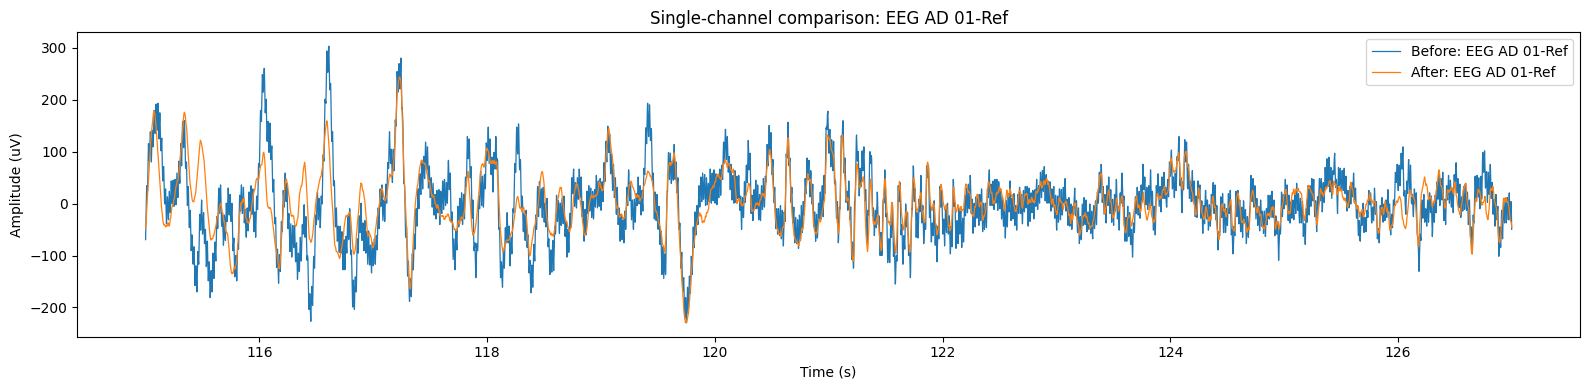

In [16]:
# ============================================================
# 7. EXAMPLE PLOT BEFORE / AFTER PREPROCESSING
# ============================================================
if PLOT_EXAMPLE_RUN is not None:
    example_channels = find_sidecar_tsv(PLOT_EXAMPLE_RUN, "channels")
    print(f"\nPlotting example run:\n{PLOT_EXAMPLE_RUN}")
    plot_before_after_preprocessing(
        edf_path=PLOT_EXAMPLE_RUN,
        channels_tsv=example_channels,
        start_sec=PLOT_START_SEC,
        duration_sec=PLOT_DURATION_SEC,
        n_channels=PLOT_CHANNELS,
    )

In [17]:
# ============================================================
# 8. PROCESS WHOLE DATASET
# ============================================================
qc_rows = []
failed = []

for run in runs:
    try:
        qc = preprocess_one_run(run, OUT_ROOT)
        qc_rows.append(asdict(qc))
    except Exception as e:
        failed.append({
            "edf_path": str(run.edf_path),
            "subject": run.subject,
            "session": run.session,
            "task": run.task,
            "acquisition": run.acquisition,
            "run": run.run,
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })
        print(f"[FAILED] {run.edf_path}")
        print(traceback.format_exc())

manifest_path = OUT_ROOT / "manifest.csv"
failed_path = OUT_ROOT / "failed_runs.csv"

qc_df = pd.DataFrame(qc_rows)
if not qc_df.empty:
    qc_df.to_csv(manifest_path, index=False)

failed_df = pd.DataFrame(failed)
if not failed_df.empty:
    failed_df.to_csv(failed_path, index=False)

print("\nDone.")
print(f"Manifest: {manifest_path}")
if not failed_df.empty:
    print(f"Failed runs log: {failed_path}")




[RUN] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP060_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.edf


C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  onset_mask = tmp["_desc_norm"].str.contains(
C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:220: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  offset_mask = tmp["_desc_norm"].str.contains(


  sfreq=500.000 Hz | channels kept=36/59 | windows kept=972/973 | ictal=797 | nonictal=175

[RUN] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP060_ses-presurgery_task-ictal_acq-seeg_run-02_ieeg.edf


C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  onset_mask = tmp["_desc_norm"].str.contains(
C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:220: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  offset_mask = tmp["_desc_norm"].str.contains(


  sfreq=500.000 Hz | channels kept=36/59 | windows kept=741/741 | ictal=565 | nonictal=176

[RUN] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP060_ses-presurgery_task-ictal_acq-seeg_run-03_ieeg.edf


...

  sfreq=1024.000 Hz | channels kept=149/162 | windows kept=379/557 | ictal=203 | nonictal=176

[RUN] D:\HUP dataset\sub-HUP190\ses-presurgery\ieeg\sub-HUP190_ses-presurgery_task-ictal_acq-seeg_run-02_ieeg.edf


C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  onset_mask = tmp["_desc_norm"].str.contains(
C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:220: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  offset_mask = tmp["_desc_norm"].str.contains(


  sfreq=1024.000 Hz | channels kept=149/162 | windows kept=380/549 | ictal=236 | nonictal=144

[RUN] D:\HUP dataset\sub-HUP190\ses-presurgery\ieeg\sub-HUP190_ses-presurgery_task-ictal_acq-seeg_run-03_ieeg.edf


C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:216: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  onset_mask = tmp["_desc_norm"].str.contains(
C:\Users\ajars\AppData\Local\Temp\ipykernel_23024\3950968106.py:220: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  offset_mask = tmp["_desc_norm"].str.contains(


  sfreq=1024.000 Hz | channels kept=149/162 | windows kept=468/473 | ictal=297 | nonictal=171

[RUN] D:\HUP dataset\sub-HUP190\ses-presurgery\ieeg\sub-HUP190_ses-presurgery_task-interictal_acq-seeg_run-01_ieeg.edf
  sfreq=1024.000 Hz | channels kept=149/162 | windows kept=271/298 | ictal=0 | nonictal=271

[RUN] D:\HUP dataset\sub-HUP190\ses-presurgery\ieeg\sub-HUP190_ses-presurgery_task-interictal_acq-seeg_run-02_ieeg.edf
  sfreq=1024.000 Hz | channels kept=149/162 | windows kept=272/298 | ictal=0 | nonictal=272

Done.
Manifest: D:\HUP_processed_binary\manifest.csv
Failed runs log: D:\HUP_processed_binary\failed_runs.csv


In [18]:
# ============================================================
# 9. SUMMARY
# ============================================================
if not qc_df.empty:
    print("\n========== DATASET SUMMARY ==========")
    print("Subjects:", qc_df["subject"].nunique())
    print("Runs processed:", len(qc_df))
    print("Total windows kept:", int(qc_df["n_windows_kept"].sum()))
    print("Total ictal windows:", int(qc_df["n_ictal_windows"].sum()))
    print("Total nonictal windows:", int(qc_df["n_nonictal_windows"].sum()))

    ratio = qc_df["n_ictal_windows"].sum() / max(qc_df["n_nonictal_windows"].sum(), 1)
    print(f"Ictal/nonictal ratio: {ratio:.4f}")

    summary = (
        qc_df.groupby(["subject", "task"], dropna=False)[["n_windows_kept", "n_ictal_windows", "n_nonictal_windows"]]
        .sum()
        .reset_index()
        .sort_values(["subject", "task"])
    )

    print("\nPer-subject/task summary:")
    print(summary.head(100))

    print("\nQC head:")
    print(qc_df.head())

if not failed_df.empty:
    print("\nFailed runs head:")
    print(failed_df[["subject", "task", "run", "edf_path", "error"]].head(20))


========== DATASET SUMMARY ==========
Subjects: 56
Runs processed: 312
Total windows kept: 149715
Total ictal windows: 83952
Total nonictal windows: 65763
Ictal/nonictal ratio: 1.2766

Per-subject/task summary:
       subject        task  n_windows_kept  n_ictal_windows  \
0   sub-HUP060       ictal            2430             1903   
1   sub-HUP060  interictal             575                0   
2   sub-HUP064       ictal             573              397   
3   sub-HUP064  interictal             298                0   
4   sub-HUP065       ictal            1595             1067   
..         ...         ...             ...              ...   
95  sub-HUP177  interictal             584                0   
96  sub-HUP179       ictal             707              358   
97  sub-HUP179  interictal             594                0   
98  sub-HUP180       ictal            1724              909   
99  sub-HUP180  interictal             574                0   

    n_nonictal_windows  
0     